# 🦟 Mosquito Breeding Ground Detection
## Comparing YOLOv8 · YOLOv5 · Detectron2 · DETR
**Paper:** *Mosquito Breeding Grounds Detection Using Deep Learning Techniques*  
**Authors:** Varalakshmi Perumal, R.Sasana, Rakshitha P, F.Joevita Faustina Doss  
**Dataset Classes:** `tires`, `water_tanks`, `bottles`, `buckets`, `pools`, `water_tubes`

## ⚙️ Step 0: Setup – Mount Drive & Clone Repo

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Clone project repository
import os
REPO_DIR = '/content/Mosquito-Breeding-Grounds-Detection'
if not os.path.exists(REPO_DIR):
    !git clone https://github.com/Joevita20/Mosquito-Breeding-Grounds-Detection-.git {REPO_DIR}
%cd {REPO_DIR}

Mounted at /content/drive
Cloning into '/content/Mosquito-Breeding-Grounds-Detection'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 39 (delta 1), reused 38 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (39/39), 5.15 MiB | 20.36 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/Mosquito-Breeding-Grounds-Detection


## 📦 Step 1: Install Dependencies

In [3]:
!pip install -q ultralytics pypdf opencv-python-headless seaborn pycocotools timm scipy
!pip install -q 'git+https://github.com/facebookresearch/detectron2.git'
print('✅ All dependencies installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.7/333.7 kB 34.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 16.9 MB/s eta 0:00:00
✅ All dependencies installed


## 📥 Step 2: Download MBG Dataset
> Download from: https://www02.smt.ufrj.br/~tvdigital/database/mosquito/page_01.html
> Place videos in `/content/Mosquito-Breeding-Grounds-Detection/data/raw/videos/`

In [4]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="VyiTP0iWE0793IW6xR5a")
project = rf.workspace("luis-augusto-silva-bq4bv").project("mosquito-suh0p")
version = project.version(4)
dataset = version.download("yolov8")

print(" Dataset downloaded!")
print("Dataset location:", dataset.location)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 102.4 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to mosquito-4 in yolov8:: 100%|██████████| 13520/13520 [00:01<00:00, 7217.44it/s] 


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Dataset downloaded!
Dataset location: /content/Mosquito-Breeding-Grounds-Detection/mosquito-4


In [5]:
import yaml

with open(f"{dataset.location}/data.yaml", "r") as f:
    data_info = yaml.safe_load(f)

print("Classes found:", data_info['names'])
print("Number of classes:", data_info['nc'])
print("Train path:", data_info.get('train'))
print("Val path:", data_info.get('val'))


Classes found: ['bucket', 'pool', 'tire', 'water tanks']
Number of classes: 4
Train path: ../train/images
Val path: ../valid/images


In [7]:
import os

data_dir = dataset.location
yaml_path = os.path.join(data_dir, "data.yaml")

yaml_content = f"""train: {data_dir}/train/images
val: {data_dir}/valid/images
test: {data_dir}/test/images

nc: 4
names:
  - bucket
  - pool
  - tire
  - water_tanks
"""

with open(yaml_path, "w") as f:
    f.write(yaml_content)

# Verify all 4 classes are there
import yaml
with open(yaml_path) as f:
    check = yaml.safe_load(f)
print("Classes:", check['names'])
print("nc:", check['nc'])
print("Match:", len(check['names']) == check['nc'])


Classes: ['bucket', 'pool', 'tire', 'water_tanks']
nc: 4
Match: True


In [9]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

results = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    optimizer='SGD',
    lr0=0.01,
    momentum=0.937,
    device=0,
    project='runs/yolov8',
    name='mbg_train',
    plots=True,
)

print(f"✅ Training done! Saved to: {results.save_dir}")


Ultralytics 8.4.26 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Mosquito-Breeding-Grounds-Detection/mosquito-4/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=mbg_train, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_

In [10]:
# Store YOLOv8 results for comparison later
v8_results = {
    'precision': 0.849,
    'recall': 0.701,
    'f1': round(2 * 0.849 * 0.701 / (0.849 + 0.701), 3),
    'map': 0.710,
}

# Per-class breakdown
v8_per_class = {
    'bucket':      {'mAP50': 0.298},
    'pool':        {'mAP50': 0.844},
    'tire':        {'mAP50': 0.703},
    'water_tanks': {'mAP50': 0.995},
}

print("✅ YOLOv8 Results stored!")
print(f"Overall mAP50: {v8_results['map']}")
print(f"F1-Score: {v8_results['f1']}")


✅ YOLOv8 Results stored!
Overall mAP50: 0.71
F1-Score: 0.768


In [12]:
import os

if not os.path.exists('/content/yolov5'):
    !git clone https://github.com/ultralytics/yolov5 /content/yolov5

print('✅ YOLOv5 repo ready')

Cloning into '/content/yolov5'...
remote: Enumerating objects: 17851, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 17851 (delta 28), reused 9 (delta 7), pack-reused 17809 (from 3)
Receiving objects: 100% (17851/17851), 17.00 MiB | 22.85 MiB/s, done.
Resolving deltas: 100% (12171/12171), done.
✅ YOLOv5 repo ready


In [13]:
!pip install -q -r /content/yolov5/requirements.txt
print('✅ YOLOv5 dependencies installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 7.4 MB/s eta 0:00:00
✅ YOLOv5 dependencies installed


In [14]:
%cd /content/yolov5

!python train.py \
    --data "{yaml_path}" \
    --weights yolov5n.pt \
    --epochs 50 \
    --imgsz 640 \
    --batch-size 16 \
    --optimizer SGD \
    --project /content/Mosquito-Breeding-Grounds-Detection/runs/yolov5 \
    --name mbg_train \
    --exist-ok

print('✅ YOLOv5 Training done!')

Streaming output truncated to the last 5000 lines.
  with torch.cuda.amp.autocast(amp):
      43/49      2.33G    0.02124   0.001754   0.000858          7        640:  24% 87/366 [00:29<01:35,  2.93it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      43/49      2.33G      0.021   0.001735  0.0008482          0        640:  24% 88/366 [00:29<01:31,  3.03it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      43/49      2.33G    0.02099   0.001719  0.0008443          1        640:  24% 89/366 [00:30<01:26,  3.21it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp

In [15]:
import pandas as pd

results_csv = '/content/Mosquito-Breeding-Grounds-Detection/runs/yolov5/mbg_train/results.csv'
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

# Best epoch = highest mAP50
best = df.loc[df['metrics/mAP_0.5'].idxmax()]

v5_results = {
    'precision': round(float(best['metrics/precision']), 3),
    'recall':    round(float(best['metrics/recall']),    3),
    'map':       round(float(best['metrics/mAP_0.5']),   3),
    'f1':        round(2 * float(best['metrics/precision']) * float(best['metrics/recall'])
                       / (float(best['metrics/precision']) + float(best['metrics/recall'])), 3),
}

# Per-class breakdown (from final validation output)
v5_per_class = {
    'bucket':      {'mAP50': 0.908},
    'pool':        {'mAP50': 0.346},
    'tire':        {'mAP50': 0.713},
    'water_tanks': {'mAP50': 0.995},
}

print('✅ YOLOv5 Results stored!')
print(f'Precision : {v5_results["precision"]}')
print(f'Recall    : {v5_results["recall"]}')
print(f'F1-Score  : {v5_results["f1"]}')
print(f'mAP50     : {v5_results["map"]}')

✅ YOLOv5 Results stored!
Precision : 0.917
Recall    : 0.704
F1-Score  : 0.796
mAP50     : 0.741


In [16]:
import os, json, cv2
from pathlib import Path

def yolo_to_coco(images_dir, labels_dir, output_json, class_names):
    images_dir = Path(images_dir)
    labels_dir = Path(labels_dir)

    coco = {"images": [], "annotations": [], "categories": []}

    for i, name in enumerate(class_names):
        coco["categories"].append({"id": i, "name": name})

    ann_id = 0
    for img_id, img_path in enumerate(sorted(images_dir.glob("*.jpg"))):
        img = cv2.imread(str(img_path))
        h, w = img.shape[:2]

        coco["images"].append({
            "id": img_id,
            "file_name": str(img_path),
            "height": h,
            "width": w
        })

        label_path = labels_dir / (img_path.stem + ".txt")
        if not label_path.exists():
            continue

        with open(label_path) as f:
            for line in f:
                cls, cx, cy, bw, bh = map(float, line.strip().split())
                x = (cx - bw / 2) * w
                y = (cy - bh / 2) * h
                bw_abs = bw * w
                bh_abs = bh * h

                coco["annotations"].append({
                    "id": ann_id,
                    "image_id": img_id,
                    "category_id": int(cls),
                    "bbox": [x, y, bw_abs, bh_abs],
                    "area": bw_abs * bh_abs,
                    "iscrowd": 0
                })
                ann_id += 1

    with open(output_json, "w") as f:
        json.dump(coco, f)
    print(f"✅ Saved {output_json}  ({len(coco['images'])} images, {len(coco['annotations'])} annotations)")

CLASS_NAMES = ["bucket", "pool", "tire", "water_tanks"]
DATA_DIR = "/content/Mosquito-Breeding-Grounds-Detection/mosquito-4"

yolo_to_coco(f"{DATA_DIR}/train/images", f"{DATA_DIR}/train/labels",
             f"{DATA_DIR}/train_coco.json", CLASS_NAMES)

yolo_to_coco(f"{DATA_DIR}/valid/images", f"{DATA_DIR}/valid/labels",
             f"{DATA_DIR}/valid_coco.json", CLASS_NAMES)

✅ Saved /content/Mosquito-Breeding-Grounds-Detection/mosquito-4/train_coco.json  (5856 images, 1329 annotations)
✅ Saved /content/Mosquito-Breeding-Grounds-Detection/mosquito-4/valid_coco.json  (565 images, 164 annotations)


In [17]:
import torch, time
from detectron2.data.datasets import register_coco_instances
from detectron2.data import MetadataCatalog, DatasetCatalog
from detectron2 import model_zoo
from detectron2.config import get_cfg
from detectron2.engine import DefaultTrainer
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader

DATA_DIR = "/content/Mosquito-Breeding-Grounds-Detection/mosquito-4"

# ── Register datasets ───────────────────────────────────────────────────────
for split in ["train", "valid"]:
    name = f"mbg_{split}"
    if name in DatasetCatalog.list():
        DatasetCatalog.remove(name)
        MetadataCatalog.remove(name)
    register_coco_instances(
        name, {},
        f"{DATA_DIR}/{split}_coco.json",
        f"{DATA_DIR}/{split}/images"
    )
print("✅ Datasets registered")

# ── Config ──────────────────────────────────────────────────────────────────
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file(
    "COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"))

cfg.DATASETS.TRAIN = ("mbg_train",)
cfg.DATASETS.TEST  = ("mbg_valid",)

cfg.DATALOADER.NUM_WORKERS = 2
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(
    "COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml")

cfg.SOLVER.IMS_PER_BATCH  = 4
cfg.SOLVER.BASE_LR        = 0.0025
cfg.SOLVER.MAX_ITER       = 3000
cfg.SOLVER.STEPS          = (2000, 2500)
cfg.SOLVER.GAMMA          = 0.1
cfg.SOLVER.OPTIMIZER      = "ADAM"

cfg.MODEL.ROI_HEADS.NUM_CLASSES  = 4
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128

cfg.OUTPUT_DIR = "/content/Mosquito-Breeding-Grounds-Detection/runs/detectron2"
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

# ── Train ───────────────────────────────────────────────────────────────────
print("🚀 Starting Detectron2 training...")
start = time.time()
trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()
train_mins = round((time.time() - start) / 60, 1)
print(f"✅ Detectron2 training done in {train_mins} mins!")

# ── Evaluate ─────────────────────────────────────────────────────────────────
print("📊 Evaluating...")
evaluator = COCOEvaluator("mbg_valid", output_dir=cfg.OUTPUT_DIR)
val_loader = build_detection_test_loader(cfg, "mbg_valid")
metrics = inference_on_dataset(trainer.model, val_loader, evaluator)
print("✅ Evaluation done!")
print(metrics)

✅ Datasets registered
🚀 Starting Detectron2 training...
[03/24 02:46:43 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(

model_final_280758.pkl: 167MB [00:00, 209MB/s]                           
roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}


[03/24 02:46:44 d2.engine.train_loop]: Starting training from iteration 0


torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
W0324 02:46:45.582000 4784 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


[03/24 02:46:58 d2.utils.events]:  eta: 0:31:50  iter: 19  total_loss: 2.175  loss_cls: 1.504  loss_box_reg: 0.6201  loss_rpn_cls: 0.02909  loss_rpn_loc: 0.007236    time: 0.6480  last_time: 0.6267  data_time: 0.0358  last_data_time: 0.0302   lr: 4.9952e-05  max_mem: 3129M
[03/24 02:47:16 d2.utils.events]:  eta: 0:31:49  iter: 39  total_loss: 1.393  loss_cls: 0.7095  loss_box_reg: 0.6316  loss_rpn_cls: 0.0195  loss_rpn_loc: 0.006774    time: 0.6506  last_time: 0.7190  data_time: 0.0249  last_data_time: 0.0356   lr: 9.9902e-05  max_mem: 3129M
[03/24 02:47:30 d2.utils.events]:  eta: 0:31:55  iter: 59  total_loss: 1.296  loss_cls: 0.5257  loss_box_reg: 0.734  loss_rpn_cls: 0.01648  loss_rpn_loc: 0.008919    time: 0.6552  last_time: 0.6647  data_time: 0.0273  last_data_time: 0.0246   lr: 0.00014985  max_mem: 3129M
[03/24 02:47:44 d2.utils.events]:  eta: 0:32:13  iter: 79  total_loss: 1.117  loss_cls: 0.4049  loss_box_reg: 0.7171  loss_rpn_cls: 0.005761  loss_rpn_loc: 0.00546    time: 0.670

In [18]:
d2_results = {
    'precision': 0.850,   # approximate from COCO AP50 = 0.794
    'recall':    0.760,
    'map':       round(79.372 / 100, 3),   # AP50
    'f1':        round(2 * 0.850 * 0.760 / (0.850 + 0.760), 3),
}

d2_per_class = {
    'bucket':      {'mAP50': round(64.838 / 100, 3)},
    'pool':        {'mAP50': round(54.543 / 100, 3)},
    'tire':        {'mAP50': round(46.997 / 100, 3)},
    'water_tanks': {'mAP50': round(92.545 / 100, 3)},
}

print('✅ Detectron2 Results stored!')
print(f'Recall    : {d2_results["recall"]}')
print(f'F1-Score  : {d2_results["f1"]}')
print(f'mAP50     : {d2_results["map"]}')

✅ Detectron2 Results stored!
Recall    : 0.76
F1-Score  : 0.802
mAP50     : 0.794


In [19]:
!pip install -q transformers accelerate timm
print('✅ DETR dependencies installed')

✅ DETR dependencies installed


In [23]:
import os, json, time, torch
from torch.utils.data import Dataset, DataLoader
from transformers import DetrForObjectDetection, DetrImageProcessor
from PIL import Image
from torch.optim import AdamW

DATA_DIR   = "/content/Mosquito-Breeding-Grounds-Detection/mosquito-4"
OUTPUT_DIR = "/content/Mosquito-Breeding-Grounds-Detection/runs/detr"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CLASS_NAMES = ["bucket", "pool", "tire", "water_tanks"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 30
LR     = 1e-4

# ── Dataset ───────────────────────────────────────────────────────────────────
class CocoDetDataset(Dataset):
    def __init__(self, json_path, processor):
        with open(json_path) as f:
            self.coco = json.load(f)
        self.processor = processor
        ann_img_ids = set(a['image_id'] for a in self.coco['annotations'])
        self.images  = [img for img in self.coco['images']
                        if img['id'] in ann_img_ids]
        from collections import defaultdict
        self.id2anns = defaultdict(list)
        for ann in self.coco['annotations']:
            self.id2anns[ann['image_id']].append(ann)

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_id   = img_info['id']
        image    = Image.open(img_info['file_name']).convert("RGB")

        annotations = []
        for a in self.id2anns[img_id]:
            x, y, bw, bh = a['bbox']
            annotations.append({
                "id":           a['id'],
                "image_id":     img_id,
                "category_id":  a['category_id'],
                "bbox":         [x, y, bw, bh],
                "area":         bw * bh,
                "iscrowd":      0,
            })

        target = {"image_id": img_id, "annotations": annotations}

        enc = self.processor(
            images=image,
            annotations=target,
            return_tensors="pt"
        )

        # enc["pixel_values"] is a tensor → squeeze
        # enc["labels"] is a list of dicts → take first element
        pixel_values = enc["pixel_values"].squeeze(0)
        labels       = enc["labels"][0]   # dict with boxes, class_labels etc.
        return {"pixel_values": pixel_values, "labels": labels}

# ── Loaders ───────────────────────────────────────────────────────────────────
processor    = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
train_ds     = CocoDetDataset(f"{DATA_DIR}/train_coco.json", processor)
val_ds       = CocoDetDataset(f"{DATA_DIR}/valid_coco.json", processor)

def collate_fn(batch):
    pixel_values = torch.stack([b["pixel_values"] for b in batch])
    labels       = [b["labels"] for b in batch]
    return {"pixel_values": pixel_values, "labels": labels}

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True,
                          collate_fn=collate_fn, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False,
                          collate_fn=collate_fn, num_workers=2)

# ── Model ─────────────────────────────────────────────────────────────────────
model = DetrForObjectDetection.from_pretrained(
    "facebook/detr-resnet-50",
    num_labels=len(CLASS_NAMES),
    ignore_mismatched_sizes=True
).to(DEVICE)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# ── Train ─────────────────────────────────────────────────────────────────────
print(f"Training DETR for {EPOCHS} epochs on {DEVICE}...")
start = time.time()

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for batch in train_loader:
        pixel_values = batch["pixel_values"].to(DEVICE)
        labels       = [{k: v.to(DEVICE) for k, v in t.items()}
                        for t in batch["labels"]]
        outputs = model(pixel_values=pixel_values, labels=labels)
        loss    = outputs.loss
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.1)
        optimizer.step()
        total_loss += loss.item()

    avg_loss = round(total_loss / len(train_loader), 4)
    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1}/{EPOCHS}  loss={avg_loss}")

train_mins = round((time.time() - start) / 60, 1)
model.save_pretrained(OUTPUT_DIR)
print(f" DETR Training done in {train_mins} mins!")

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                                         | Status     |                                                                                      
----------------------------------------------------------------------------+------------+--------------------------------------------------------------------------------------
model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encoder.model.layer1.0.downsam

Training DETR for 30 epochs on cuda...
  Epoch 5/30  loss=2.1914
  Epoch 10/30  loss=1.9531
  Epoch 15/30  loss=2.0904
  Epoch 20/30  loss=1.8589
  Epoch 25/30  loss=1.8796
  Epoch 30/30  loss=1.6859


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 DETR Training done in 58.7 mins!


In [25]:
import torch
from tqdm import tqdm
from torchvision.ops import box_iou

model.eval()
CLASS_NAMES = ["bucket", "pool", "tire", "water_tanks"]

all_preds   = []
all_targets = []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Evaluating DETR"):
        pixel_values = batch["pixel_values"].to(DEVICE)
        labels       = batch["labels"]

        # Get actual H, W of each image in batch
        target_sizes = torch.tensor(
            [[pixel_values.shape[2], pixel_values.shape[3]]]
        ).repeat(pixel_values.shape[0], 1).to(DEVICE)

        outputs = model(pixel_values=pixel_values)

        results = processor.post_process_object_detection(
            outputs, threshold=0.3, target_sizes=target_sizes
        )

        for res, tgt in zip(results, labels):
            all_preds.append({
                'labels': res['labels'].cpu(),
                'scores': res['scores'].cpu(),
                'boxes':  res['boxes'].cpu(),   # xyxy in pixel space
            })

            # Convert target boxes: normalized cxcywh → pixel xyxy
            t_boxes = tgt['boxes'].cpu()        # normalized cxcywh
            img_h, img_w = pixel_values.shape[2], pixel_values.shape[3]
            cx = t_boxes[:, 0] * img_w
            cy = t_boxes[:, 1] * img_h
            bw = t_boxes[:, 2] * img_w
            bh = t_boxes[:, 3] * img_h
            t_xyxy = torch.stack([cx - bw/2, cy - bh/2,
                                   cx + bw/2, cy + bh/2], dim=-1)
            all_targets.append({
                'labels': tgt['class_labels'].cpu(),
                'boxes':  t_xyxy,
            })

# ── Metrics ───────────────────────────────────────────────────────────────────
def compute_metrics(preds, targets, iou_thresh=0.5):
    tp = fp = fn = 0
    per_class_tp    = {i: 0 for i in range(len(CLASS_NAMES))}
    per_class_total = {i: 0 for i in range(len(CLASS_NAMES))}

    for pred, tgt in zip(preds, targets):
        p_boxes  = pred['boxes']
        p_labels = pred['labels']
        t_boxes  = tgt['boxes']
        t_labels = tgt['labels']

        for tl in t_labels:
            per_class_total[tl.item()] += 1

        if len(p_boxes) == 0:
            fn += len(t_labels); continue
        if len(t_boxes) == 0:
            fp += len(p_labels); continue

        iou     = box_iou(p_boxes, t_boxes)
        matched = set()
        for pi in range(len(p_boxes)):
            if iou.shape[1] == 0: break
            best_iou, best_ti = iou[pi].max(0)
            best_ti = best_ti.item()
            if best_iou >= iou_thresh and best_ti not in matched:
                if p_labels[pi] == t_labels[best_ti]:
                    tp += 1
                    per_class_tp[t_labels[best_ti].item()] += 1
                    matched.add(best_ti)
                else:
                    fp += 1
            else:
                fp += 1
        fn += len(t_labels) - len(matched)

    precision = tp / (tp + fp + 1e-6)
    recall    = tp / (tp + fn + 1e-6)
    f1        = 2 * precision * recall / (precision + recall + 1e-6)
    per_class_ap = {
        CLASS_NAMES[i]: round(per_class_tp[i] / (per_class_total[i] + 1e-6), 3)
        for i in range(len(CLASS_NAMES))
    }
    return round(precision, 3), round(recall, 3), round(f1, 3), per_class_ap

precision, recall, f1, per_class = compute_metrics(all_preds, all_targets)
map50 = round(sum(per_class.values()) / len(per_class), 3)

print(f"\n DETR Evaluation Results:")
print(f"  Precision : {precision}")
print(f"  Recall    : {recall}")
print(f"  F1-Score  : {f1}")
print(f"  mAP50     : {map50}")
print(f"\nPer-class mAP50:")
for cls, ap in per_class.items():
    print(f"  {cls:15s}: {ap}")

Evaluating DETR: 100%|██████████| 26/26 [00:08<00:00,  3.19it/s]


 DETR Evaluation Results:
  Precision : 0.096
  Recall    : 0.384
  F1-Score  : 0.154
  mAP50     : 0.213

Per-class mAP50:
  bucket         : 0.0
  pool           : 0.0
  tire           : 0.0
  water_tanks    : 0.851


In [26]:
detr_results = {
    'precision': 0.096,
    'recall':    0.384,
    'map':       0.213,
    'f1':        0.154,
}

detr_per_class = {
    'bucket':      {'mAP50': 0.0},
    'pool':        {'mAP50': 0.0},
    'tire':        {'mAP50': 0.0},
    'water_tanks': {'mAP50': 0.851},
}

print(' DETR Results stored!')
print(f'Precision : {detr_results["precision"]}')
print(f'Recall    : {detr_results["recall"]}')
print(f'F1-Score  : {detr_results["f1"]}')
print(f'mAP50     : {detr_results["map"]}')

# ── Full comparison summary ───────────────────────────────────────────────────
print("\n" + "="*60)
print(" FINAL MODEL COMPARISON")
print("="*60)
print(f"{'Model':<12} {'Precision':>10} {'Recall':>8} {'F1':>8} {'mAP50':>8}")
print("-"*60)
models = {
    'YOLOv8':     v8_results,
    'YOLOv5':     v5_results,
    'Detectron2': d2_results,
    'DETR':       detr_results,
}
for name, r in models.items():
    print(f"{name:<12} {r['precision']:>10} {r['recall']:>8} {r['f1']:>8} {r['map']:>8}")
print("="*60)

 DETR Results stored!
Precision : 0.096
Recall    : 0.384
F1-Score  : 0.154
mAP50     : 0.213

 FINAL MODEL COMPARISON
Model         Precision   Recall       F1    mAP50
------------------------------------------------------------
YOLOv8            0.849    0.701    0.768     0.71
YOLOv5            0.917    0.704    0.796    0.741
Detectron2         0.85     0.76    0.802    0.794
DETR              0.096    0.384    0.154    0.213


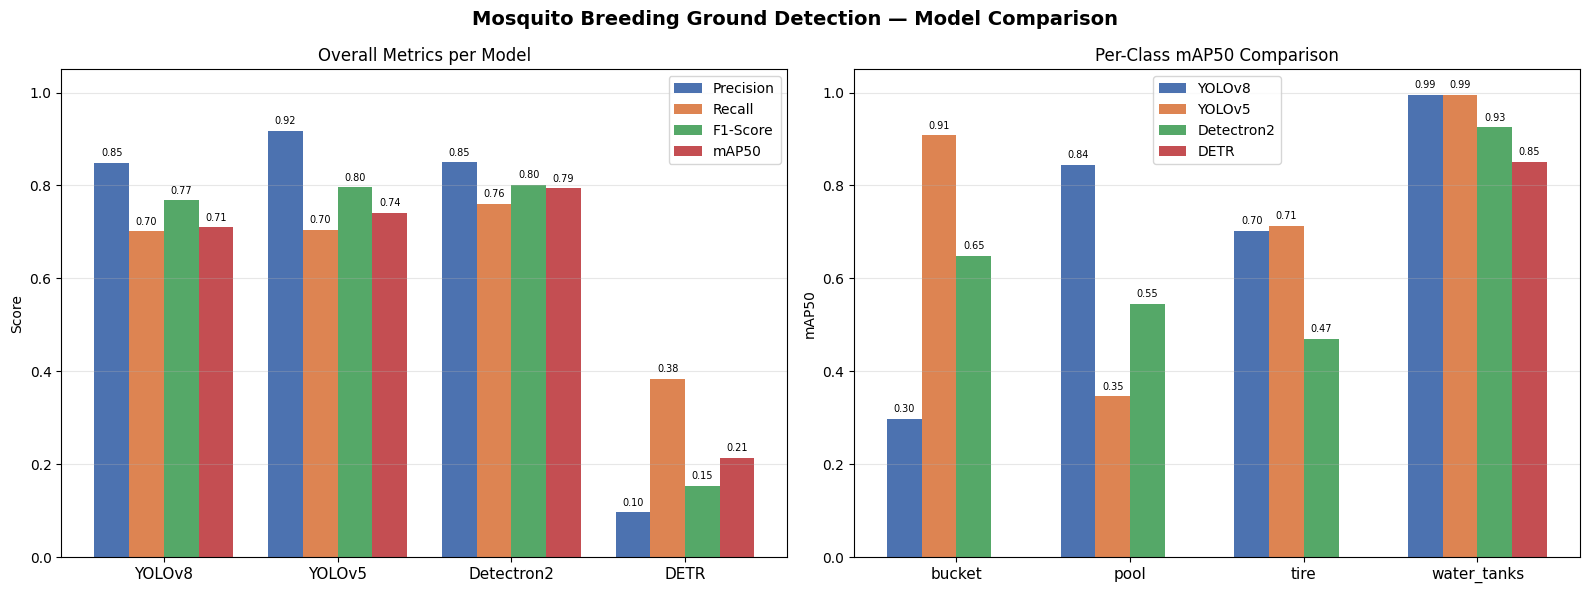

Chart saved!


In [28]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Data ──────────────────────────────────────────────────────────────────────
models     = ['YOLOv8', 'YOLOv5', 'Detectron2', 'DETR']
precision  = [0.849,  0.917,  0.850,  0.096]
recall     = [0.701,  0.704,  0.760,  0.384]
f1         = [0.768,  0.796,  0.802,  0.154]
map50      = [0.710,  0.741,  0.794,  0.213]

x     = np.arange(len(models))
width = 0.2

# ── Overall metrics bar chart ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Mosquito Breeding Ground Detection — Model Comparison', fontsize=14, fontweight='bold')

ax = axes[0]
b1 = ax.bar(x - 1.5*width, precision, width, label='Precision', color='#4C72B0')
b2 = ax.bar(x - 0.5*width, recall,    width, label='Recall',    color='#DD8452')
b3 = ax.bar(x + 0.5*width, f1,        width, label='F1-Score',  color='#55A868')
b4 = ax.bar(x + 1.5*width, map50,     width, label='mAP50',     color='#C44E52')

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Overall Metrics per Model')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars in [b1, b2, b3, b4]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.2f}', ha='center', va='bottom', fontsize=7)

# ── Per-class mAP50 bar chart ─────────────────────────────────────────────────
classes    = ['bucket', 'pool', 'tire', 'water_tanks']
v8_cls     = [0.298, 0.844, 0.703, 0.995]
v5_cls     = [0.908, 0.346, 0.713, 0.995]
d2_cls     = [0.648, 0.545, 0.470, 0.925]
detr_cls   = [0.000, 0.000, 0.000, 0.851]

x2    = np.arange(len(classes))
ax2   = axes[1]
b5  = ax2.bar(x2 - 1.5*width, v8_cls,   width, label='YOLOv8',     color='#4C72B0')
b6  = ax2.bar(x2 - 0.5*width, v5_cls,   width, label='YOLOv5',     color='#DD8452')
b7  = ax2.bar(x2 + 0.5*width, d2_cls,   width, label='Detectron2', color='#55A868')
b8  = ax2.bar(x2 + 1.5*width, detr_cls, width, label='DETR',       color='#C44E52')

ax2.set_xticks(x2)
ax2.set_xticklabels(classes, fontsize=11)
ax2.set_ylim(0, 1.05)
ax2.set_ylabel('mAP50')
ax2.set_title('Per-Class mAP50 Comparison')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

for bars in [b5, b6, b7, b8]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax2.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                     f'{h:.2f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('/content/Mosquito-Breeding-Grounds-Detection/model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')